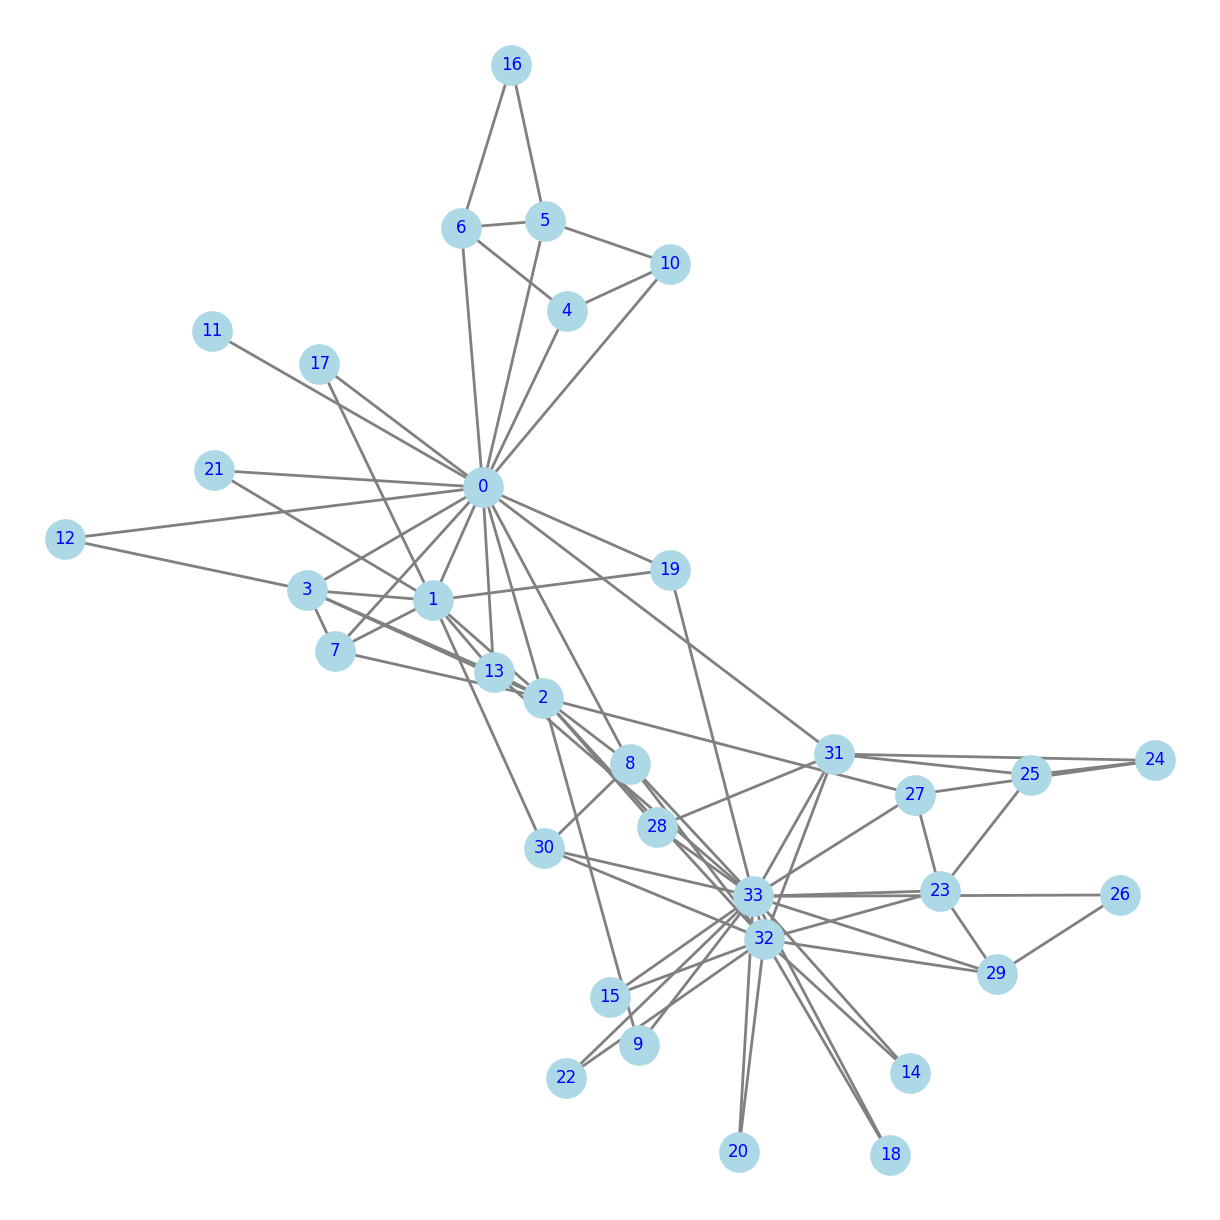

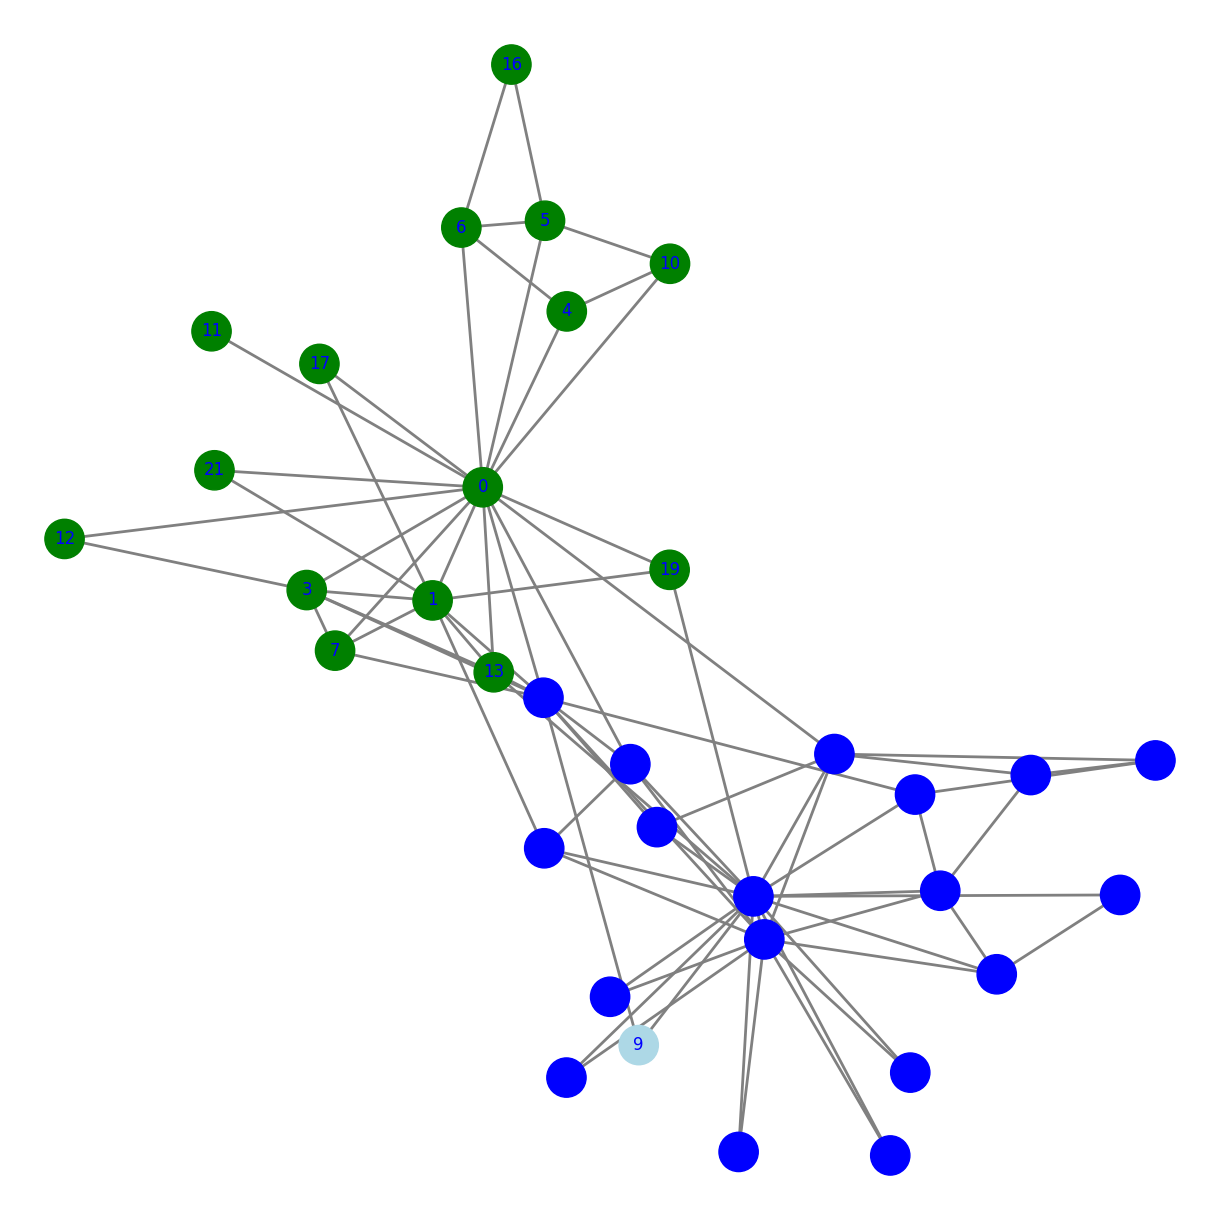

In [13]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman
from itertools import islice

# Color palette excluding grayscale
COLOR_PALETTE = [
    "#008000", "#0000FF", "#ADD8E6", "#E0FFFF", "#FFFF00",
    "#FFA500", "#FF8C00", "#800080"
]

# Label color
LABEL_COLOR = "#0000FF"  # Blue for clear visibility

# Create the Karate Club graph
G = nx.karate_club_graph()
pos = nx.spring_layout(G, seed=42)  # Fixed layout

# Helper to draw a graph
def draw_graph(graph, node_colors=None):
    plt.figure(figsize=(12, 12))
    nx.draw(
        graph,
        pos,
        with_labels=True,
        labels={node: node for node in graph.nodes()},
        node_color=node_colors or "#ADD8E6",
        edge_color="#808080",
        node_size=800,
        font_size=12,
        font_color=LABEL_COLOR,
        width=2,
    )
    plt.margins(0)
    plt.axis("off")
    plt.show()

# Helper to detect communities using Girvan-Newman
def get_communities(graph, k):
    communities_generator = girvan_newman(graph)
    top_k_communities = next(islice(communities_generator, k - 1, k))
    return [list(community) for community in top_k_communities]

# Plain network visualization
draw_graph(G)

# Detect communities (k=2 for simplicity)
k = 2
communities = get_communities(G, k)

# Assign colors to communities
community_colors = {
    node: COLOR_PALETTE[i % len(COLOR_PALETTE)]
    for i, community in enumerate(communities)
    for node in community
}
node_colors = [community_colors[node] for node in G.nodes()]

# Community visualization
draw_graph(G, node_colors)